# Validation des actifs actifs

Je me concentre ici sur Langer Wald (éolien) et Perleberg (solaire), les deux actifs actifs de mon portefeuille allemand.

## Charger les configurations

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pvlib

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / 'src').is_dir() and (candidate / 'config' / 'assets.yaml').is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError('Impossible de trouver la racine du projet Qair.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_assets

assets = load_assets(PROJECT_ROOT / 'config' / 'assets.yaml')
portfolio_assets = {
    asset_id: config
    for asset_id, config in assets.items()
    if config.get('portfolio_status') == 'active' and config['country'] == 'Germany'
}
print('Racine du projet :', PROJECT_ROOT)
print('Actifs étudiés :', ', '.join(portfolio_assets))

Racine du projet : C:\Users\djamo\Desktop\DossierIsidore\Qair_virtual_trading_lab
Actifs étudiés : langer_wald, perleberg


Racine du projet : C:\Users\djamo\Desktop\DossierIsidore\Qair_virtual_trading_lab
Actifs étudiés : langer_wald, perleberg


## Définir le périmètre

Je garde uniquement les deux actifs allemands actifs. Les autres sites ne sont pas utilisés dans cette analyse.

In [3]:
asset_overview = pd.DataFrame([
    {
        'asset': asset_id,
        'status': config.get('portfolio_status', 'active'),
        'technology': config['technology'],
        'country': config['country'],
        'capacity_mw': config['capacity_mw'],
    }
    for asset_id, config in portfolio_assets.items()
])
display(asset_overview)

,asset,status,technology,country,capacity_mw
0,langer_wald,active,wind,Germany,31.0
1,perleberg,active,solar,Germany,22.1


Les deux sites retenus forment le portefeuille étudié dans la zone DE-LU : 31 MW d'éolien à Langer Wald et 22,1 MW de solaire à Perleberg. Les autres actifs restent dans la configuration, mais ils ne doivent pas entrer dans cette validation.

## Vérifier les données historiques

Je vérifie d'abord la période couverte, la fréquence à 15 minutes et l'absence de valeurs manquantes avant de travailler sur la production.

In [4]:
checks = []
for asset_id in portfolio_assets:
    path = PROJECT_ROOT / 'data' / 'asset_data' / f'{asset_id}_historical_reanalysis_15m.parquet'
    if not path.exists():
        checks.append({'asset': asset_id, 'reanalysis_file': False})
        continue

    data = pd.read_parquet(path)
    timestamps = pd.to_datetime(data['timestamp'], utc=True)
    checks.append({
        'asset': asset_id,
        'reanalysis_file': True,
        'rows': len(data),
        'start_utc': timestamps.min(),
        'end_utc': timestamps.max(),
        'duplicates': int(timestamps.duplicated().sum()),
        'irregular_15m': int(timestamps.diff().dropna().ne(pd.Timedelta(minutes=15)).sum()),
        'missing_values': int(data.isna().sum().sum()),
        'production_min_mw': data['production_mw'].min(),
        'production_max_mw': data['production_mw'].max(),
        'capacity_mw': data['capacity_mw'].iloc[0],
        'energy_mwh': data['production_mw'].sum() * 0.25,
        'mean_capacity_factor': data['capacity_factor'].mean(),
    })

pd.DataFrame(checks)

,asset,reanalysis_file,rows,start_utc,end_utc,duplicates,irregular_15m,missing_values,production_min_mw,production_max_mw,capacity_mw,energy_mwh,mean_capacity_factor
0,langer_wald,True,128640,2023-01-01 00:00:00+00:00,2026-09-01 23:45:00+00:00,0,0,0,0.0,31.000000,31.0,386880.335931,0.388060
1,perleberg,True,93600,2024-01-01 00:00:00+00:00,2026-09-01 23:45:00+00:00,0,0,0,0.0,18.244249,22.1,67798.253941,0.131102


Les fichiers ERA5 sont complets sur la période contrôlée : pas de doublon, pas de trou à 15 minutes et pas de valeur manquante. La production reste dans les limites physiques des deux actifs. Cette étape vérifie la qualité du fichier, pas encore le réalisme parfait de la météo ou de la courbe de puissance.

## Vérifier la cible de production

Je recalcule la production à partir de la météo stockée. Cela permet de vérifier que le fichier utilise bien la configuration actuelle de chaque actif.

In [5]:
from src.generation import solar, wind

validation_rows = []
for asset_id, config in portfolio_assets.items():
    path = PROJECT_ROOT / 'data' / 'asset_data' / f'{asset_id}_historical_reanalysis_15m.parquet'
    if not path.exists():
        continue

    data = pd.read_parquet(path)
    target_variables = config['historical_reanalysis']['target_variables']
    weather = data.set_index(pd.to_datetime(data['timestamp'], utc=True))
    target_weather = weather[target_variables]
    regenerated = (
        wind.transform(target_weather, config)
        if config['technology'] == 'wind'
        else solar.transform(target_weather, config)
    )
    validation_rows.append({
        'asset': asset_id,
        'technology': config['technology'],
        'capacity_mw': config['capacity_mw'],
        'rows_checked': len(data),
        'target_max_abs_difference_mw': (
            data['production_mw'].to_numpy() - regenerated['production_mw'].to_numpy()
        ).__abs__().max(),
        'capacity_factor_max_abs_difference': (
            data['capacity_factor'].to_numpy() - regenerated['capacity_factor'].to_numpy()
        ).__abs__().max(),
        'stored_factor_max_abs_difference': (
            data['capacity_factor'] - data['production_mw'] / config['capacity_mw']
        ).abs().max(),
    })

physical_validation = pd.DataFrame(validation_rows)
display(physical_validation)

,asset,technology,capacity_mw,rows_checked,target_max_abs_difference_mw,capacity_factor_max_abs_difference,stored_factor_max_abs_difference
0,langer_wald,wind,31.0,128640,0.0,0.0,1.110223e-16
1,perleberg,solar,22.1,93600,0.0,0.0,0.000000e+00


Les écarts sont nuls : la production enregistrée correspond bien à la météo ERA5 et aux paramètres actuels des actifs. On contrôle aussi le facteur de charge stocké, car une erreur d'unité entre MW et MWh pourrait sinon passer inaperçue.

La météo J-1 sera utilisée plus tard, au moment du test du modèle. Ici, je travaille uniquement avec l'historique ERA5.

## Regarder les profils de production

Je regarde le profil solaire selon la saison, le lien entre rayonnement et production, puis la relation entre vent au moyeu et production éolienne.

,solar_max_production_when_sun_below_horizon_mw,solar_daylight_radiation_production_correlation,wind_max_production_mw,wind_capacity_mw
0,0.0,0.968017,31.0,31


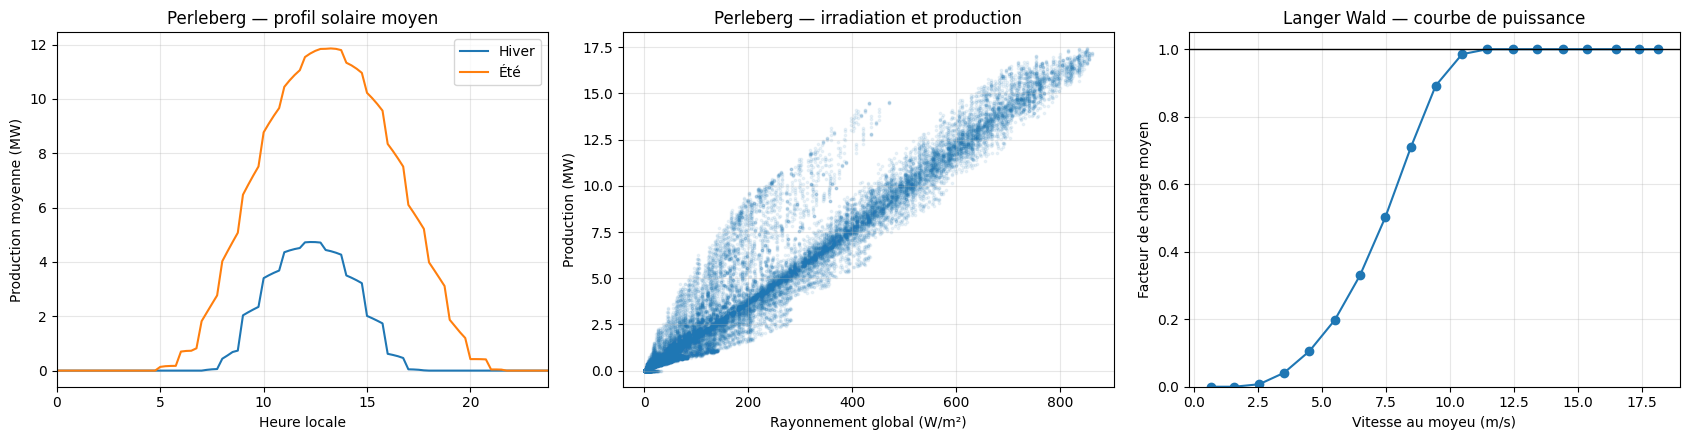

In [6]:
solar_data = pd.read_parquet(
    PROJECT_ROOT / 'data' / 'asset_data' / 'perleberg_historical_reanalysis_15m.parquet'
)
solar_timestamp = pd.to_datetime(solar_data['timestamp'], utc=True)
solar_time = solar_timestamp.dt.tz_convert('Europe/Berlin')
# Le profil solaire est plus lisible en heure locale allemande.
solar_position = pvlib.solarposition.get_solarposition(
    solar_timestamp, assets['perleberg']['latitude'], assets['perleberg']['longitude']
)
solar_data['sun_below_horizon'] = solar_position['apparent_zenith'].to_numpy() >= 90
solar_data['local_hour'] = solar_time.dt.hour + solar_time.dt.minute / 60
solar_data['season'] = np.select(
    [solar_time.dt.month.isin([12, 1, 2]), solar_time.dt.month.isin([6, 7, 8])],
    ['Hiver', 'Été'],
    default='Autre',
)
solar_data = solar_data[solar_data['season'].isin(['Hiver', 'Été'])]

# La vitesse à 166 m correspond à la hauteur de moyeu du parc.
wind_data = pd.read_parquet(
    PROJECT_ROOT / 'data' / 'asset_data' / 'langer_wald_historical_reanalysis_15m.parquet'
)
wind_data['wind_speed_hub_m'] = wind_data['wind_speed_100m'] * (
    assets['langer_wald']['hub_height_m'] / 100
) ** 0.2
wind_data['wind_bin'] = pd.cut(
    wind_data['wind_speed_hub_m'], bins=np.arange(0, 31, 1), right=False
)
wind_profile = wind_data.groupby('wind_bin', observed=True).agg(
    wind_speed_hub_m=('wind_speed_hub_m', 'mean'),
    capacity_factor=('capacity_factor', 'mean'),
).dropna()

night_max_mw = solar_data.loc[solar_data['sun_below_horizon'], 'production_mw'].max()
daylight = solar_data.loc[solar_data['shortwave_radiation'] > 1]
profile_checks = pd.DataFrame([{
    'solar_max_production_when_sun_below_horizon_mw': night_max_mw,
    'solar_daylight_radiation_production_correlation': daylight['shortwave_radiation'].corr(daylight['production_mw']),
    'wind_max_production_mw': wind_data['production_mw'].max(),
    'wind_capacity_mw': assets['langer_wald']['capacity_mw'],
}])
display(profile_checks)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for season, values in solar_data.groupby('season'):
    profile = values.groupby('local_hour')['production_mw'].mean()
    axes[0].plot(profile.index, profile.values, label=season)
axes[0].set(title='Perleberg — profil solaire moyen', xlabel='Heure locale', ylabel='Production moyenne (MW)', xlim=(0, 23.75))
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(daylight['shortwave_radiation'], daylight['production_mw'], s=3, alpha=0.08)
axes[1].set(title='Perleberg — irradiation et production', xlabel='Rayonnement global (W/m²)', ylabel='Production (MW)')
axes[1].grid(alpha=0.3)

axes[2].plot(wind_profile['wind_speed_hub_m'], wind_profile['capacity_factor'], marker='o')
axes[2].axhline(1, color='black', linewidth=1)
axes[2].set(title='Langer Wald — courbe de puissance', xlabel='Vitesse au moyeu (m/s)', ylabel='Facteur de charge moyen', ylim=(0, 1.05))
axes[2].grid(alpha=0.3)

fig.tight_layout()

Les profils obtenus sont physiquement cohérents : le solaire est nul lorsque le soleil est sous l'horizon, sa production suit fortement le rayonnement, et l'éolien atteint sa capacité lorsque la vitesse au moyeu devient suffisante. La météo ERA5 fournit donc une cible plus réaliste pour la suite, même si elle reste une réanalyse et non une mesure directe sur site.